# Deeply Learning 4: LoRA (Low Rank Adaptation) - Math, Intuition and Implementation from Scratch

Fine-tuning large language models is one of the most powerful tools we have for adapting pre-trained models to specific tasks. However, full fine-tuning comes with a brutal cost, as for each downstream task, we need to store and update a *full* copy of the model's parameters. LLaMA 3.1 8B has 8 billion parameters. LLaMA 3.1 70B has 70 billion. Multiply that by the number of tasks you care about, and things get impractical fast.

[LoRA (Low-Rank Adaptation)](https://arxiv.org/abs/2106.09685) by Hu et al. (2021) offers a surprisingly elegant solution: instead of updating all the parameters, we inject small, trainable low-rank matrices into the model and freeze everything else. The result? We can fine-tune a model by training **less than 0.5%** of its parameters and match full fine-tuning performance.

In this post, we will build LoRA from scratch:
1. Understand *why* it works (intrinsic dimensionality)
2. Derive the underlying math step by step.
3. Implement a `LoRATrainer` layer in PyTorch.
4. Fine-tune GPT-2 for sentiment classification on SST-2. We will compare full fine-tuning vs. LoRA.
5. Merge the LoRA weights back for zero-cost inference.

Let's dive in!


## Setup

In [1]:
!pip install transformers datasets accelerate torchvision -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
from dataclasses import dataclass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## 1. The Expensive Fine-Tuning Problem

Let's think about the concrete cost of fine-tuning a model with AdamW optimizer in mixed precision (FP16 parameters/gradients, FP32 optimizer states). Here is what we need to store **per downstream task**.

| Component | Size (for LLaMA 3.1 70B, mixed precision) |
|-----------|------------------------|
| Model parameters | 70B × 2 bytes = **140 GB** |
| Gradients | 70B × 2 bytes = **140 GB** |
| AdamW first moment (m) | 70B × 4 bytes = **280 GB** |
| AdamW second moment (v) | 70B × 4 bytes = **280 GB** |
| **Total** | **~840 GB** |

And this only gets worse as models grow:

| Model | Params | Fine-Tuning Memory (AdamW, mixed precision) | Min. GPUs (80 GB A100s) |
|-------|--------|---------------------------------------------|--------------------------|
| LLaMA 3.1 8B | 8B | ~96 GB | 2 |
| LLaMA 3.1 70B | 70B | ~840 GB | 11 |
| LLaMA 3.1 405B | 405B | ~4.9 TB | 62 |

That's **840 GB** just to fine-tune LLaMA 3.1 70B on a *single* task. You'd need at least **11 A100 GPUs** (80 GB each). For the 405B model, you're looking at a cluster of 62 GPUs. If you have 10 downstream tasks, that's tens of thousands of GPU-hours and petabytes of stored checkpoints, with each one requiring a full backward pass through tens of billions of parameters.

The natural question is: **do we really need to update all those parameters?**

Let's verify this arithmetic with GPT-2 small, we can extrapolate this for the larger model. Even at 124M parameters, the cost of full fine-tuning adds up quickly. Then we'll project what this looks like at 70B scale.

In [3]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

from transformers import GPT2Model

model = GPT2Model.from_pretrained("gpt2")
total_params = sum(p.numel() for p in model.parameters())

print(f"GPT-2 small total parameters: {total_params:,}")
print(f"Memory for full fine-tuning (FP32, with AdamW): {total_params * 4 * 4 / 1e9:.2f} GB")
print(f"Memory for 10 task-specific checkpoints: {total_params * 4 * 10 / 1e9:.2f} GB")
print()
print(f"Now scale that to 70B parameters (LLaMA 3.1 70B, mixed precision):")
print(f"  Fine-tuning memory: {70e9 * 12 / 1e9:.0f} GB  (params + grads in FP16, optimizer states in FP32)")
print(f"  10 task checkpoints: {70e9 * 2 * 10 / 1e9:.0f} GB")

del model

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 small total parameters: 124,439,808
Memory for full fine-tuning (FP32, with AdamW): 1.99 GB
Memory for 10 task-specific checkpoints: 4.98 GB

Now scale that to 70B parameters (LLaMA 3.1 70B, mixed precision):
  Fine-tuning memory: 840 GB  (params + grads in FP16, optimizer states in FP32)
  10 task checkpoints: 1400 GB


## 2. Intrinsic Dimensionality

LoRA leverages a key concept called *Intrinsic Dimensionality*. Let's understand it better. [Aghajanyan et al. (2020)](https://arxiv.org/abs/2012.13255) showed something remarkable: the weight updates $\Delta W$ learned during fine-tuning don't actually use the full parameter space. They live in a **surprisingly low-dimensional subspace**.

The intuition is: A weight matrix $W \in \mathbb{R}^{d \times k}$ has $d \times k$ parameters. But the *change* $\Delta W = W_{\text{fine-tuned}} - W_{\text{pre-trained}}$ needed to adapt the model to a new task might have a much lower rank. Pre-training already learned a rich, general representation. Fine-tuning is a small *adjustment* that nudges the model in a specific direction within the vast parameter space, and that direction can be captured by a low-rank matrix.

### A Quick Refresher: Matrix Rank and SVD

Any matrix $M \in \mathbb{R}^{d \times k}$ can be decomposed via Singular Value Decomposition (SVD):

$$M = U \Sigma V^T$$

where $U \in \mathbb{R}^{d \times d}$, $\Sigma \in \mathbb{R}^{d \times k}$ (diagonal with singular values $\sigma_1 \geq \sigma_2 \geq \dots$), and $V \in \mathbb{R}^{k \times k}$.

The **rank** of $M$ is the number of non-zero singular values. A key property: the best rank-$r$ approximation of $M$ (in Frobenius norm) is obtained by keeping only the top $r$ singular values:

$$M_r = U_r \Sigma_r V_r^T$$

If the singular values drop off quickly, a low-rank approximation captures most of the information. This is exactly what happens with $\Delta W$ during fine-tuning.

Let's verify this empirically with MNIST. We'll pre-train a small network to classify all 10 digits, then fine-tune it on a simpler binary task: odd vs. even. The binary task reuses the learned digit representations but only needs a simple readout adjustment, so we'd expect the weight update to be low-rank.

In [4]:
from torchvision import datasets, transforms

torch.manual_seed(42)

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
mnist_train = datasets.MNIST('./data', train=True, download=True, transform=mnist_transform)
mnist_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)

d_in = 28 * 28  # flattened MNIST images
d_hidden = 256

class MNISTNet(nn.Module):
    def __init__(self, d_in=784, d_hidden=256, d_out=10):
        super().__init__()
        self.fc1 = nn.Linear(d_in, d_hidden)
        self.fc2 = nn.Linear(d_hidden, d_out)

    def forward(self, x: torch.Tensor):
        x = x.flatten(1)
        return self.fc2(F.relu(self.fc1(x)))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [5]:
net = MNISTNet(d_in, d_hidden, d_out=10).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
for epoch in range(3):
    total_loss, correct, total = 0, 0, 0
    for images, labels in mnist_loader:
        images, labels = images.to(device), labels.to(device)
        logits = net(images)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.detach().argmax(1) == labels).sum().item()
        total += labels.size(0)
    print(f"Pre-train epoch {epoch+1}/3 | Loss: {total_loss/total:.4f} | Acc: {correct/total:.2%}")

W_pretrained = {name: p.data.clone() for name, p in net.named_parameters()}

# Fine-tune: odd vs. even (binary task that reuses digit features)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
for epoch in range(2):
    total_loss, correct, total = 0, 0, 0
    for images, labels in mnist_loader:
        images, labels = images.to(device), (labels % 2).to(device)
        logits = net(images)[:, :2]
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    print(f"Fine-tune epoch {epoch+1}/2 | Loss: {total_loss/total:.4f} | Acc: {correct/total:.2%}")

# Compute delta_W and its singular values
delta_W = net.fc1.weight.data - W_pretrained['fc1.weight']
U, S, V = torch.linalg.svd(delta_W)

S_normalized = S / S.sum()
cumulative = torch.cumsum(S_normalized, dim=0)

print(f"\nShape of delta_W (fc1): {delta_W.shape}")
print(f"Full rank: {min(delta_W.shape)}")
print(f"\nSingular value energy concentration:")
for r in [1, 2, 4, 8, 16]:
    print(f"  Top {r:2d} singular values capture {cumulative[r-1]:.1%} of total energy")

Pre-train epoch 1/3 | Loss: 0.2666 | Acc: 92.26%
Pre-train epoch 2/3 | Loss: 0.1098 | Acc: 96.73%
Pre-train epoch 3/3 | Loss: 0.0744 | Acc: 97.74%
Fine-tune epoch 1/2 | Loss: 0.2899 | Acc: 90.69%
Fine-tune epoch 2/2 | Loss: 0.0832 | Acc: 97.19%

Shape of delta_W (fc1): torch.Size([256, 784])
Full rank: 256

Singular value energy concentration:
  Top  1 singular values capture 12.9% of total energy
  Top  2 singular values capture 21.3% of total energy
  Top  4 singular values capture 33.3% of total energy
  Top  8 singular values capture 47.4% of total energy
  Top 16 singular values capture 61.1% of total energy


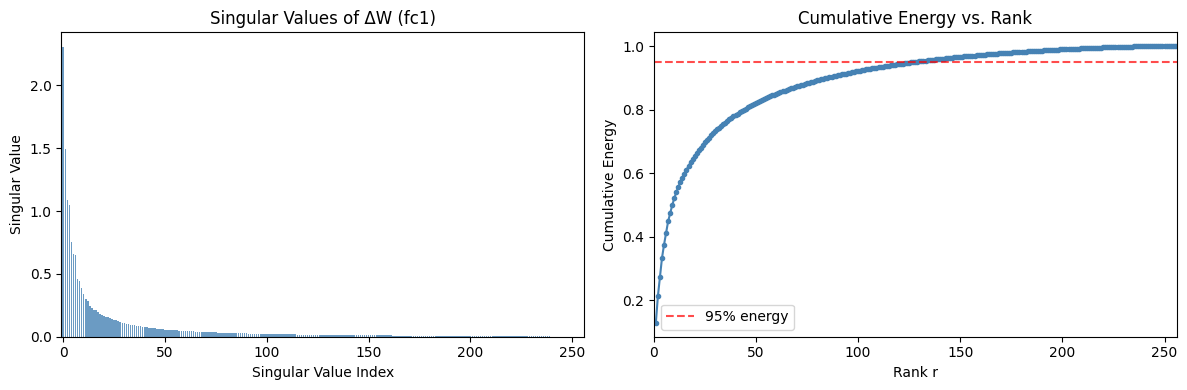


Rank needed to capture 95% of ΔW energy: 128 out of 256
That's only 50.0% of the full rank!


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(len(S)), S.cpu().numpy(), color='steelblue', alpha=0.8)
ax1.set_xlabel('Singular Value Index')
ax1.set_ylabel('Singular Value')
ax1.set_title('Singular Values of ΔW (fc1)')
ax1.set_xlim(-1, len(S))

ax2.plot(range(1, len(cumulative)+1), cumulative.cpu().numpy(),
         'o-', color='steelblue', markersize=3)
ax2.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% energy')
ax2.set_xlabel('Rank r')
ax2.set_ylabel('Cumulative Energy')
ax2.set_title('Cumulative Energy vs. Rank')
ax2.legend()
ax2.set_xlim(0, len(S))

plt.tight_layout()
plt.show()

# Find rank needed for 95% energy
rank_95 = (cumulative >= 0.95).nonzero(as_tuple=True)[0][0].item() + 1
print(f"\nRank needed to capture 95% of ΔW energy: {rank_95} out of {min(delta_W.shape)}")
print(f"That's only {rank_95/min(delta_W.shape):.1%} of the full rank!")

The singular values drop off, with the top few directions carrying a disproportionate share of the update energy. Even in this small 2-layer network, the weight update is far from uniformly distributed across all 256 singular values (where each would contribute ~0.4%).

That said, the effect here is modest because our toy network has only 256 hidden units. It genuinely *needs* much of its capacity. In large language models with millions or billions of parameters, the concentration is far more dramatic. [Aghajanyan et al.](https://arxiv.org/abs/2012.13255) showed that models like RoBERTa-Large have an intrinsic dimensionality of just a few hundred, despite having 355 million parameters. We'll see this ourselves in Section 8, where we analyze the singular values of LoRA adapters trained on GPT-2.

This is the fundamental reason LoRA works: **we don't need to learn a full-rank update. A low-rank one is enough.**


## 3. The LoRA Formulation

Now that we understand *why* low-rank updates are sufficient, let's formalize the idea.

### The Core Idea

For a pre-trained weight matrix $W_0 \in \mathbb{R}^{d \times k}$, LoRA constrains the weight update to be low-rank by representing it as the product of two smaller matrices:

$$h = W_0 x + \Delta W x = W_0 x + BA x$$

where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$, with $r \ll \min(d, k)$.

That's it. That's the whole idea. We freeze $W_0$ (no gradients, no optimizer states) and only train $A$ and $B$. Here's the architecture visually:

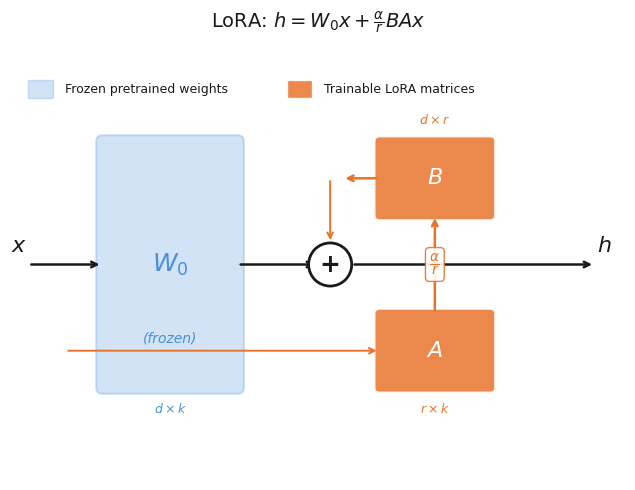

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_aspect('equal')
ax.axis('off')

frozen_color = '#4A90D9'
frozen_alpha = 0.25
lora_color = '#E8732C'
lora_alpha = 0.85
text_color = '#1a1a1a'

# Frozen W₀ (large rectangle)
w_rect = patches.FancyBboxPatch((1.5, 1.5), 2.2, 4.0,
                                 boxstyle="round,pad=0.1",
                                 facecolor=frozen_color, alpha=frozen_alpha,
                                 edgecolor=frozen_color, linewidth=1.5)
ax.add_patch(w_rect)
ax.text(2.6, 3.5, '$W_0$', fontsize=18, ha='center', va='center',
        color=frozen_color, fontweight='bold')
ax.text(2.6, 2.3, '(frozen)', fontsize=10, ha='center', va='center',
        color=frozen_color, style='italic')
ax.text(2.6, 1.15, '$d \\times k$', fontsize=9, ha='center', va='center',
        color=frozen_color)

# LoRA A (narrow rectangle, down-project)
a_rect = patches.FancyBboxPatch((6.0, 1.5), 1.8, 1.2,
                                 boxstyle="round,pad=0.08",
                                 facecolor=lora_color, alpha=lora_alpha,
                                 edgecolor='white', linewidth=1.5)
ax.add_patch(a_rect)
ax.text(6.9, 2.1, '$A$', fontsize=16, ha='center', va='center',
        color='white', fontweight='bold')
ax.text(6.9, 1.15, '$r \\times k$', fontsize=9, ha='center', va='center',
        color=lora_color)

# LoRA B (narrow rectangle, up-project)
b_rect = patches.FancyBboxPatch((6.0, 4.3), 1.8, 1.2,
                                 boxstyle="round,pad=0.08",
                                 facecolor=lora_color, alpha=lora_alpha,
                                 edgecolor='white', linewidth=1.5)
ax.add_patch(b_rect)
ax.text(6.9, 4.9, '$B$', fontsize=16, ha='center', va='center',
        color='white', fontweight='bold')
ax.text(6.9, 5.85, '$d \\times r$', fontsize=9, ha='center', va='center',
        color=lora_color)

arrow_kw = dict(arrowstyle='->', lw=1.8, color=text_color)
lora_arrow_kw = dict(arrowstyle='->', lw=1.8, color=lora_color)

# x input arrow -> W₀
ax.annotate('', xy=(1.5, 3.5), xytext=(0.3, 3.5), arrowprops=arrow_kw)
ax.text(0.15, 3.8, '$x$', fontsize=16, ha='center', va='center',
        color=text_color, fontweight='bold')

# W₀ output arrow -> sum node
ax.annotate('', xy=(5.0, 3.5), xytext=(3.7, 3.5), arrowprops=arrow_kw)

# x input splits down to A (curved path)
ax.annotate('', xy=(6.0, 2.1), xytext=(0.9, 2.1),
            arrowprops=dict(arrowstyle='->', lw=1.4, color=lora_color,
                           connectionstyle='arc3,rad=0.0'))

# A -> B (vertical arrow)
ax.annotate('', xy=(6.9, 4.3), xytext=(6.9, 2.7), arrowprops=lora_arrow_kw)

# B -> sum node
ax.annotate('', xy=(5.4, 4.9), xytext=(6.0, 4.9),
            arrowprops=lora_arrow_kw)

# Sum node (circle with +)
sum_circle = plt.Circle((5.2, 3.5), 0.35, facecolor='white',
                         edgecolor=text_color, linewidth=2, zorder=5)
ax.add_patch(sum_circle)
ax.text(5.2, 3.5, '+', fontsize=18, ha='center', va='center',
        color=text_color, fontweight='bold', zorder=6)

# Sum node arrow down from B path
ax.annotate('', xy=(5.2, 3.85), xytext=(5.2, 4.9),
            arrowprops=dict(arrowstyle='->', lw=1.4, color=lora_color))

# Output arrow from sum -> h
ax.annotate('', xy=(9.5, 3.5), xytext=(5.55, 3.5), arrowprops=arrow_kw)
ax.text(9.65, 3.8, '$h$', fontsize=16, ha='center', va='center',
        color=text_color, fontweight='bold')

# Scaling label
ax.text(6.9, 3.5, '$\\frac{\\alpha}{r}$', fontsize=14, ha='center',
        va='center', color=lora_color, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=lora_color, alpha=0.9))

# Legend
ax.add_patch(patches.Rectangle((0.3, 6.2), 0.4, 0.3,
             facecolor=frozen_color, alpha=frozen_alpha, edgecolor=frozen_color))
ax.text(0.9, 6.35, 'Frozen pretrained weights', fontsize=9,
        va='center', color=text_color)
ax.add_patch(patches.Rectangle((4.5, 6.2), 0.4, 0.3,
             facecolor=lora_color, alpha=lora_alpha, edgecolor='white'))
ax.text(5.1, 6.35, 'Trainable LoRA matrices', fontsize=9,
        va='center', color=text_color)

ax.set_title('LoRA: $h = W_0 x + \\frac{\\alpha}{r} B A x$',
             fontsize=14, pad=15, color=text_color)
plt.tight_layout()
plt.show()

### Why this decomposition?

Any rank-$r$ matrix can be expressed as a product of two matrices with inner dimension $r$. This follows directly from SVD: if $\Delta W = U_r \Sigma_r V_r^T$ has rank $r$, we can absorb $\Sigma_r$ into either factor and write it as a product of a $d \times r$ and an $r \times k$ matrix.

LoRA simply **parameterizes** $\Delta W$ in this factored form from the start. Rather than learning a full $d \times k$ matrix and hoping it turns out low-rank, we *enforce* the low-rank structure by construction. This is where the parameter savings come from:

$$\text{Full } \Delta W: d \times k \text{ parameters}$$
$$\text{LoRA } (B, A): d \times r + r \times k \text{ parameters}$$

For $d = k = 768$ (GPT-2) and $r = 8$:
- Full: $768 \times 768 = 589,824$
- LoRA: $768 \times 8 + 8 \times 768 = 12,288$
- **Reduction: 48×**


### Initialization: Starting from Zero

LoRA initializes:
- $A \sim \mathscr{N}(0, \sigma^2)$ (Kaiming uniform in practice)
- $B = 0$

This means $\Delta W = BA = 0$ at the start of training. The model begins **exactly** at the pre-trained checkpoint. No random perturbation, no initial degradation. This is crucial because the pre-trained weights already encode valuable representations, and we want to *refine* them, not destroy them on the first forward pass.

Why not initialize both to small random values? Because $BA$ with both random would be a random rank-$r$ matrix, a non-zero perturbation that could push the model off its pre-trained loss surface before any training signal is received.

### The Scaling Factor: $\alpha / r$

The full forward pass with LoRA is:

$$h = W_0 x + \frac{\alpha}{r} B A x$$

where $\alpha$ is a constant (often set equal to $r$ or $2r$).

Why do we need this? Consider what happens when we change the rank $r$. With more columns in $A$ and more rows in $B$, the magnitude of $BA$ naturally scales with $r$. The $\alpha / r$ factor normalizes this out, so that:

- When you double $r$, you don't need to halve the learning rate
- $\alpha$ becomes a single hyperparameter that controls the magnitude of the LoRA update independent of rank
- In practice, a common default is $\alpha = 16$ with $r = 8$, giving a scaling factor of 2

We can think of $\alpha$ as a "learning rate multiplier" specifically for the LoRA branch. It lets you tune how aggressively the model adapts without touching the global learning rate.

### Which Layers to Adapt?

The original paper examines applying LoRA to different projection matrices in the attention layer:

| Target | Matrices | Description |
|--------|----------|-------------|
| $W_Q$ | Query projection | What to attend to |
| $W_K$ | Key projection | What to be attended by |
| $W_V$ | Value projection | What information to pass |
| $W_O$ | Output projection | How to combine heads |

The paper found that adapting $W_Q$ and $W_V$ together gives the best trade-off. In practice, many implementations also include $W_K$, $W_O$, and even MLP layers. The more layers you adapt, the more expressive your adaptation, at the cost of more trainable parameters. We'll stick with $W_Q$ and $W_V$ for this post.

## 4. Parameter Savings: A Worked Example

Let's compute the exact savings for GPT-2 small. This is *very* satisfying arithmetic.

In [8]:
# GPT-2 small architecture
d_model = 768
n_layers = 12
n_heads = 12
d_head = d_model // n_heads  # 64

# Each attention layer has Wq, Wk, Wv, Wo, each of shape (d_model, d_model)
# We'll apply LoRA to Wq and Wv

params_per_target_layer = d_model * d_model  # 768 * 768 = 589,824
full_ft_params = 2 * n_layers * params_per_target_layer  # Wq and Wv across all layers

print("=== Full Fine-Tuning (Wq + Wv only) ===")
print(f"Parameters per matrix: {params_per_target_layer:,}")
print(f"Total trainable (Wq + Wv, all layers): {full_ft_params:,}")

print("\n=== LoRA ===")
for r in [1, 2, 4, 8, 16]:
    lora_per_matrix = d_model * r + r * d_model  # B (d_model x r) + A (r x d_model)
    lora_total = 2 * n_layers * lora_per_matrix
    reduction = full_ft_params / lora_total
    print(f"  r={r:2d}: {lora_total:>8,} params ({reduction:5.1f}× reduction, "
          f"{lora_total/full_ft_params:.2%} of full)")

=== Full Fine-Tuning (Wq + Wv only) ===
Parameters per matrix: 589,824
Total trainable (Wq + Wv, all layers): 14,155,776

=== LoRA ===
  r= 1:   36,864 params (384.0× reduction, 0.26% of full)
  r= 2:   73,728 params (192.0× reduction, 0.52% of full)
  r= 4:  147,456 params ( 96.0× reduction, 1.04% of full)
  r= 8:  294,912 params ( 48.0× reduction, 2.08% of full)
  r=16:  589,824 params ( 24.0× reduction, 4.17% of full)


Even at $r = 8$, we're training only ~2% of the parameters we'd need for full fine-tuning of those layers. And remember, the rest of the model (embeddings, LayerNorm, MLPs) is completely frozen: zero gradients, zero optimizer states.

## 5. Implementation from Scratch

Now let's build it. We need two things:
1. A `LoRALinear` module that wraps a frozen `nn.Linear`
2. A utility to inject LoRA into a pre-trained model


### The `LoRALinear` Layer

The forward pass implements exactly the equation we derived:

$$h = W_0 x + \frac{\alpha}{r} B A x$$

We compute $xA^T$ first (projecting from $k$ to $r$ dimensions), then multiply by $B^T$ (projecting from $r$ to $d$ dimensions). This is efficient because $r$ is small, so we never materialize the full $d \times k$ matrix $BA$.

In [9]:
from transformers.pytorch_utils import Conv1D

class LoRALinear(nn.Module):
  """A Linear layer augmented with LoRA low-rank adaptation.

  Implements: h = W_0 @ x + (alpha / r) * B @ A @ x
  where W_0 is frozen and only A, B are trained.

  Supports both nn.Linear and HuggingFace's Conv1D (used by GPT-2).
  Conv1D stores weights as (in_features, out_features), transposed
  relative to nn.Linear's (out_features, in_features).
  """
  def __init__(self, original_layer: nn.Linear | Conv1D, r: int = 8, alpha: float = 16.0):
    super().__init__()
    self.original_layer = original_layer
    self.r = r
    self.alpha = alpha
    self.scaling = alpha / r
    self.is_conv1d = isinstance(original_layer, Conv1D)

    if self.is_conv1d:
        # Conv1D weight: (in_features, out_features)
        self.in_features = original_layer.weight.shape[0]
        self.out_features = original_layer.nf
    else:
        self.in_features = original_layer.in_features
        self.out_features = original_layer.out_features

    # Freeze the original weight
    self.original_layer.weight.requires_grad = False
    if self.original_layer.bias is not None:
        self.original_layer.bias.requires_grad = False

    # LoRA matrices
    # A: (r, in_features) - projects input down to rank r
    # B: (out_features, r) - projects back up to output dim
    self.lora_A = nn.Parameter(torch.empty(r, self.in_features))
    self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))

    nn.init.kaiming_uniform_(self.lora_A, a=5**0.5)
    # B is initialized to zero, so delta_W = BA = 0 at init

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    h = self.original_layer(x)

    # LoRA branch: x @ A^T @ B^T
    # x: (..., in_features) -> (..., r) -> (..., out_features)
    lora_out = x @ self.lora_A.T @ self.lora_B.T

    return h + self.scaling * lora_out

  def merge_weights(self) -> nn.Module:
    """Merge LoRA weights back into the original layer.
    After merging, this layer behaves identically to the original
    with no additional computation cost.
    """
    with torch.no_grad():
        delta_W = self.lora_B @ self.lora_A  # (out_features, in_features)
        if self.is_conv1d:
            # Conv1D weight is (in_features, out_features), so transpose
            self.original_layer.weight.add_(self.scaling * delta_W.T)
        else:
            # nn.Linear weight is (out_features, in_features)
            self.original_layer.weight.add_(self.scaling * delta_W)
    return self.original_layer

  @property
  def lora_params(self) -> int:
    return self.lora_A.numel() + self.lora_B.numel()

  def __repr__(self) -> str:
    layer_type = "Conv1D" if self.is_conv1d else "Linear"
    return (f"LoRALinear({layer_type}, in={self.in_features}, "
            f"out={self.out_features}, "
            f"r={self.r}, alpha={self.alpha}, "
            f"lora_params={self.lora_params:,})")

Let's verify the key property: at initialization, the LoRA layer produces **exactly** the same output as the original layer.

In [10]:
# Verification: LoRA at init == original (test both nn.Linear and Conv1D)
torch.manual_seed(42)
x = torch.randn(2, 10, 768)  # (batch, seq_len, d_model)

for layer_type, original in [
    ("nn.Linear", nn.Linear(768, 768)),
    ("Conv1D", Conv1D(768, 768)),
]:
    lora_layer = LoRALinear(original, r=8, alpha=16)
    with torch.no_grad():
        diff = (original(x) - lora_layer(x)).abs().max().item()
    trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in lora_layer.parameters() if not p.requires_grad)
    print(f"{layer_type}: max diff at init = {diff:.2e}, "
          f"trainable = {trainable:,}, frozen = {frozen:,}")

print("\nBoth should show ~0 diff (B is initialized to zeros, so BA = 0)")

nn.Linear: max diff at init = 0.00e+00, trainable = 12,288, frozen = 590,592
Conv1D: max diff at init = 0.00e+00, trainable = 12,288, frozen = 590,592

Both should show ~0 diff (B is initialized to zeros, so BA = 0)


### Injecting LoRA into a Pre-trained Model

Now we need a way to take a pre-trained model and replace specific `nn.Linear` layers with `LoRALinear` wrappers. We'll write a general utility that walks the module tree and swaps in LoRA layers for any linear layer whose name matches a target pattern.

In [11]:
def inject_lora(
  model: nn.Module,
  target_modules: list[str],
  r: int = 8,
  alpha: float = 16.0
  ) -> nn.Module:
  """Replace target nn.Linear layers with LoRALinear layers.

  Args:
      model: Pre-trained model to inject LoRA into
      target_modules: List of substrings to match against layer names.
                      e.g., ['c_attn'] for GPT-2's combined QKV projection,
                      or ['q_proj', 'v_proj'] for LLaMA-style models.
      r: LoRA rank
      alpha: LoRA scaling factor

  Returns:
      Model with LoRA layers injected (modified in-place)
  """
  for name, module in model.named_modules():
    if not isinstance(module, (nn.Linear, Conv1D)):
      continue
    if not any(target in name for target in target_modules):
      continue

    # Navigate to parent module and replace the child
    parts = name.split('.')
    parent = model
    for part in parts[:-1]:
      parent = getattr(parent, part)

    original_linear = getattr(parent, parts[-1])
    lora_linear = LoRALinear(original_linear, r=r, alpha=alpha)
    setattr(parent, parts[-1], lora_linear)

  # Freeze all non-LoRA parameters
  for name, param in model.named_parameters():
    if 'lora_' not in name:
        param.requires_grad = False

  return model

In [12]:
def print_trainable_params(model: nn.Module):
  """Print trainable vs total parameter counts."""
  trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
  total = sum(p.numel() for p in model.parameters())
  print(f"Trainable: {trainable:>10,} ({trainable/total:.2%})")
  print(f"Frozen:    {total - trainable:>10,} ({(total-trainable)/total:.2%})")
  print(f"Total:     {total:>10,}")
  return trainable, total

## 6. Real-World Example: Sentiment Classification with GPT-2

Now the payoff. We'll fine-tune GPT-2 for sentiment classification on SST-2 (Stanford Sentiment Treebank, binary positive/negative) and compare three approaches:

1. **Full Fine-Tuning**: Update all parameters
2. **LoRA ($r=8$)**: Only train low-rank adapters
3. **LoRA ($r=1$)**: Push it to the extreme. Can we get away with rank 1?

### Prepare the Data

In [13]:
from datasets import load_dataset
from transformers import GPT2Tokenizer

# Load SST-2
dataset = load_dataset('glue', 'sst2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

print(f"Train size: {len(dataset['train']):,}")
print(f"Validation size: {len(dataset['validation']):,}")
print(f"\nExample: {dataset['train'][4]}")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train size: 67,349
Validation size: 872

Example: {'sentence': 'on the worst revenge-of-the-nerds clichés the filmmakers could dredge up ', 'label': 0, 'idx': 4}


In [14]:
MAX_LEN = 128

def tokenize_fn(examples):
  tokens = tokenizer(
      examples['sentence'],
      padding='max_length',
      truncation=True,
      max_length=MAX_LEN,
      return_tensors=None #return lists for datasets
  )

  tokens['labels'] = examples['label']
  return tokens

In [15]:
tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=['sentence', 'idx'])
tokenized.set_format('torch')

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [31]:
#train_subset = tokenized['train'].select(range(10000))
train_subset = tokenized['train']
val_subset = tokenized['validation']

In [54]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64)

### GPT-2 for Classification

GPT-2 is a causal language model, so it doesn't have a classification head out of the box. We'll add a simple one: take the hidden state at the last non-padding token and project it to 2 classes. This is a common pattern for using decoder-only models as classifiers.

In [33]:
from transformers import GPT2Model

class GPT2ForClassification(nn.Module):
  """GPT-2 with a classification head on top.
  Uses the last non-padding token's hidden state for classification.
  """
  def __init__(self, num_labels=2):
      super().__init__()
      self.gpt2 = GPT2Model.from_pretrained('gpt2')
      self.classifier = nn.Linear(self.gpt2.config.n_embd, num_labels)
      self.num_labels = num_labels

  def forward(
      self,
      input_ids: torch.Tensor,
      attention_mask: torch.Tensor,
      labels: torch.Tensor | None = None
  ) -> tuple[torch.Tensor | None, torch.Tensor]:
      outputs = self.gpt2(input_ids=input_ids, attention_mask=attention_mask)
      hidden_states = outputs.last_hidden_state  # (batch, seq_len, d_model)

      # Get the last non-padding token for each sequence
      # attention_mask: 1 for real tokens, 0 for padding
      # Sum along seq dim to get lengths, subtract 1 for 0-indexing
      seq_lengths = attention_mask.sum(dim=1) - 1  # (batch,)
      batch_idx = torch.arange(hidden_states.size(0), device=hidden_states.device)
      pooled = hidden_states[batch_idx, seq_lengths]  # (batch, d_model)

      logits = self.classifier(pooled)  # (batch, num_labels)

      loss = None
      if labels is not None:
          loss = F.cross_entropy(logits, labels)

      return loss, logits

### Training Utilities

In [34]:
@torch.no_grad()
def evaluate(
  model: nn.Module,
  dataloader: DataLoader,
  device: torch.device
) -> tuple[float, float]:
  model.eval()
  correct = 0
  total = 0
  total_loss = 0
  for batch in dataloader:
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['labels'].to(device)

      loss, logits = model(input_ids, attention_mask, labels)
      preds = logits.argmax(dim=-1)
      correct += (preds == labels).sum().item()
      total += labels.size(0)
      total_loss += loss.item() * labels.size(0)

  return correct / total, total_loss / total


def train_model(
  model: nn.Module,
  train_loader: DataLoader,
  val_loader: DataLoader,
  epochs: int = 3,
  lr: float = 2e-5,
  device: str | torch.device = 'cuda'
) -> dict[str, list[float]]:
  model = model.to(device)
  optimizer = torch.optim.AdamW(
      filter(lambda p: p.requires_grad, model.parameters()),
      lr=lr, weight_decay=0.01
  )

  history: dict[str, list[float]] = {
      'train_loss': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []
  }

  for epoch in range(epochs):
      model.train()
      total_loss = 0
      n_batches = 0
      start_time = time.time()

      for batch in train_loader:
          input_ids = batch['input_ids'].to(device)
          attention_mask = batch['attention_mask'].to(device)
          labels = batch['labels'].to(device)

          loss, _ = model(input_ids, attention_mask, labels)

          optimizer.zero_grad()
          loss.backward()
          torch.nn.utils.clip_grad_norm_(
              filter(lambda p: p.requires_grad, model.parameters()), 1.0
          )
          optimizer.step()

          total_loss += loss.item()
          n_batches += 1

      epoch_time = time.time() - start_time
      avg_train_loss = total_loss / n_batches
      val_acc, val_loss = evaluate(model, val_loader, device)

      history['train_loss'].append(avg_train_loss)
      history['val_loss'].append(val_loss)
      history['val_acc'].append(val_acc)
      history['epoch_time'].append(epoch_time)

      print(f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.1f}s")

  return history

### Experiment 1: Full Fine-Tuning (Baseline)

In [35]:
print("=" * 60)
print("EXPERIMENT 1: Full Fine-Tuning")
print("=" * 60)

model_full = GPT2ForClassification(num_labels=2)
print("\nParameter counts:")
print_trainable_params(model_full)

history_full = train_model(model_full, train_loader, val_loader, epochs=3, lr=2e-5, device=device)

EXPERIMENT 1: Full Fine-Tuning


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Parameter counts:
Trainable: 124,441,346 (100.00%)
Frozen:             0 (0.00%)
Total:     124,441,346
Epoch 1/3 | Train Loss: 0.2850 | Val Loss: 0.2806 | Val Acc: 0.9186 | Time: 860.3s
Epoch 2/3 | Train Loss: 0.1845 | Val Loss: 0.2811 | Val Acc: 0.9140 | Time: 860.5s
Epoch 3/3 | Train Loss: 0.1475 | Val Loss: 0.3280 | Val Acc: 0.9060 | Time: 860.9s


### Experiment 2: LoRA ($r = 8$)

Now let's apply LoRA to the attention and MLP layers. We'll target all layers whose names contain `c_attn` or `c_proj`, which covers:
- `attn.c_attn`: the combined QKV projection in each attention block
- `attn.c_proj`: the attention output projection
- `mlp.c_proj`: the MLP output projection

**Note on GPT-2's architecture**: Unlike LLaMA-style models that have separate `q_proj`, `k_proj`, `v_proj` layers, GPT-2 uses HuggingFace's `Conv1D` (not `nn.Linear`) for its projections. `c_attn` combines Q, K, V into a single layer of shape `(768, 2304)`, which is 3x the model dimension for the three projections concatenated.

In [36]:
print("=" * 60)
print("EXPERIMENT 2: LoRA (r=8)")
print("=" * 60)

model_lora8 = GPT2ForClassification(num_labels=2)

# Let's first see the layer names to know what to target
# Inject LoRA into attention + MLP projections
# c_attn = combined QKV, attn.c_proj = attention output, mlp.c_proj = MLP output
print("\nAttention layer names in GPT-2:")
for name, module in model_lora8.named_modules():
  if isinstance(module, (nn.Linear, Conv1D)) and 'attn' in name:
    if isinstance(module, Conv1D):
        print(f"  {name} (Conv1D): {module.weight.shape[0]} -> {module.nf}")
    else:
        print(f"  {name} (Linear): {module.in_features} -> {module.out_features}")

EXPERIMENT 2: LoRA (r=8)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Attention layer names in GPT-2:
  gpt2.h.0.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.0.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.1.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.1.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.2.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.2.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.3.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.3.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.4.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.4.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.5.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.5.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.6.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.6.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.7.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.7.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.8.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.8.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.9.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.9.attn.c_proj (Conv1D): 768 -> 768
  gpt2.h.10.attn.c_attn (Conv1D): 768 -> 2304
  gpt2.h.10.attn.c_proj (Conv1D

In [37]:
# Inject LoRA into attention projections
# c_attn is the combined QKV projection, c_proj is the output projection
model_lora8 = inject_lora(model_lora8, target_modules=['c_attn', 'c_proj'], r=8, alpha=16)

# The classification head should also be trainable
for param in model_lora8.classifier.parameters():
  param.requires_grad = True

print("\nParameter counts after LoRA injection:")
print_trainable_params(model_lora8)

# Show the LoRA layers
print("\nLoRA layers:")
for name, module in model_lora8.named_modules():
  if isinstance(module, LoRALinear):
    print(f"  {name}: {module}")


Parameter counts after LoRA injection:
Trainable:    812,546 (0.65%)
Frozen:    124,439,808 (99.35%)
Total:     125,252,354

LoRA layers:
  gpt2.h.0.attn.c_attn: LoRALinear(Conv1D, in=768, out=2304, r=8, alpha=16, lora_params=24,576)
  gpt2.h.0.attn.c_proj: LoRALinear(Conv1D, in=768, out=768, r=8, alpha=16, lora_params=12,288)
  gpt2.h.0.mlp.c_proj: LoRALinear(Conv1D, in=3072, out=768, r=8, alpha=16, lora_params=30,720)
  gpt2.h.1.attn.c_attn: LoRALinear(Conv1D, in=768, out=2304, r=8, alpha=16, lora_params=24,576)
  gpt2.h.1.attn.c_proj: LoRALinear(Conv1D, in=768, out=768, r=8, alpha=16, lora_params=12,288)
  gpt2.h.1.mlp.c_proj: LoRALinear(Conv1D, in=3072, out=768, r=8, alpha=16, lora_params=30,720)
  gpt2.h.2.attn.c_attn: LoRALinear(Conv1D, in=768, out=2304, r=8, alpha=16, lora_params=24,576)
  gpt2.h.2.attn.c_proj: LoRALinear(Conv1D, in=768, out=768, r=8, alpha=16, lora_params=12,288)
  gpt2.h.2.mlp.c_proj: LoRALinear(Conv1D, in=3072, out=768, r=8, alpha=16, lora_params=30,720)
  g

In [38]:
history_lora8 = train_model(model_lora8, train_loader, val_loader, epochs=3, lr=3e-4, device=device)

Epoch 1/3 | Train Loss: 0.3284 | Val Loss: 0.3055 | Val Acc: 0.8956 | Time: 607.9s
Epoch 2/3 | Train Loss: 0.2420 | Val Loss: 0.2650 | Val Acc: 0.9197 | Time: 607.8s
Epoch 3/3 | Train Loss: 0.2040 | Val Loss: 0.2771 | Val Acc: 0.9117 | Time: 607.7s


### Experiment 3: LoRA ($r = 1$). How Low Can We Go?

Remember the intrinsic dimensionality insight from Section 2? Let's push it to the extreme: rank 1. Each LoRA adapter adds just $d + k$ parameters per layer, a single direction of adaptation.

In [39]:
print("=" * 60)
print("EXPERIMENT 3: LoRA (r=1)")
print("=" * 60)

model_lora1 = GPT2ForClassification(num_labels=2)
model_lora1 = inject_lora(model_lora1, target_modules=['c_attn', 'c_proj'], r=1, alpha=8)

for param in model_lora1.classifier.parameters():
    param.requires_grad = True

print("\nParameter counts after LoRA injection (r=1):")
print_trainable_params(model_lora1)

history_lora1 = train_model(model_lora1, train_loader, val_loader, epochs=3, lr=3e-4, device=device)

EXPERIMENT 3: LoRA (r=1)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Parameter counts after LoRA injection (r=1):
Trainable:    102,914 (0.08%)
Frozen:    124,439,808 (99.92%)
Total:     124,542,722
Epoch 1/3 | Train Loss: 0.3314 | Val Loss: 0.2599 | Val Acc: 0.8991 | Time: 594.7s
Epoch 2/3 | Train Loss: 0.2567 | Val Loss: 0.3067 | Val Acc: 0.9048 | Time: 594.7s
Epoch 3/3 | Train Loss: 0.2273 | Val Loss: 0.2668 | Val Acc: 0.9002 | Time: 594.6s


### Result Comparison

In [40]:
# Comparison table
results = {
    'Full Fine-Tune': {
        'val_acc': max(history_full['val_acc']),
        'params': sum(p.numel() for p in model_full.parameters() if p.requires_grad),
        'time_per_epoch': np.mean(history_full['epoch_time']),
    },
    'LoRA (r=8)': {
        'val_acc': max(history_lora8['val_acc']),
        'params': sum(p.numel() for p in model_lora8.parameters() if p.requires_grad),
        'time_per_epoch': np.mean(history_lora8['epoch_time']),
    },
    'LoRA (r=1)': {
        'val_acc': max(history_lora1['val_acc']),
        'params': sum(p.numel() for p in model_lora1.parameters() if p.requires_grad),
        'time_per_epoch': np.mean(history_lora1['epoch_time']),
    },
}

print(f"{'Method':<20} {'Val Acc':>10} {'Trainable':>12} {'% of Full':>10} {'Time/Epoch':>12}")
print("-" * 66)
full_params = results['Full Fine-Tune']['params']
for method, r in results.items():
    print(f"{method:<20} {r['val_acc']:>10.4f} {r['params']:>12,} "
          f"{r['params']/full_params:>10.2%} {r['time_per_epoch']:>10.1f}s")

Method                  Val Acc    Trainable  % of Full   Time/Epoch
------------------------------------------------------------------
Full Fine-Tune           0.9186  124,441,346    100.00%      860.5s
LoRA (r=8)               0.9197      812,546      0.65%      607.8s
LoRA (r=1)               0.9048      102,914      0.08%      594.7s


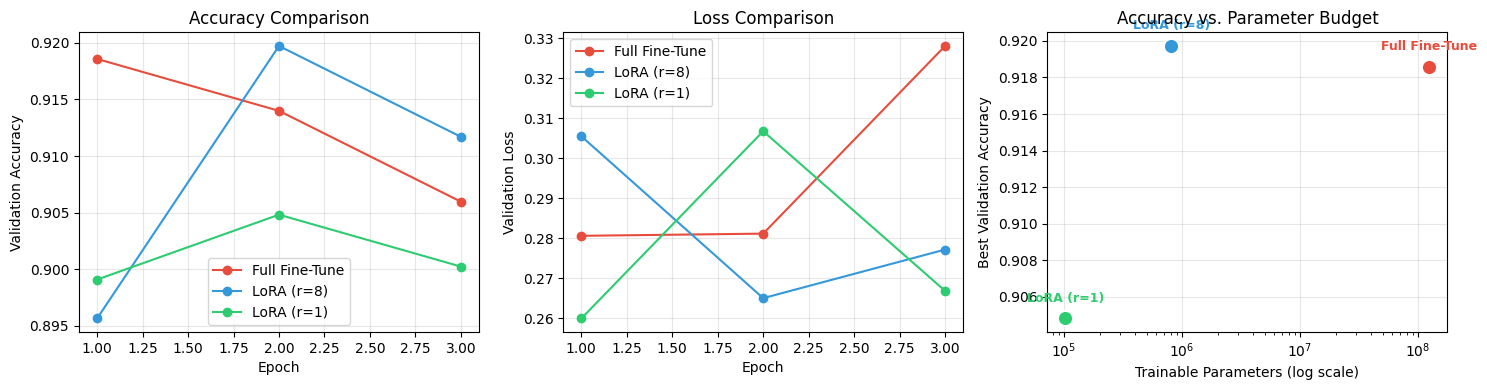

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'Full Fine-Tune': '#e74c3c', 'LoRA (r=8)': '#3498db', 'LoRA (r=1)': '#2ecc71'}

# Val accuracy over epochs
for label, h in [('Full Fine-Tune', history_full),
                  ('LoRA (r=8)', history_lora8),
                  ('LoRA (r=1)', history_lora1)]:
    axes[0].plot(range(1, len(h['val_acc'])+1), h['val_acc'], 'o-', label=label, color=colors[label])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val loss over epochs
for label, h in [('Full Fine-Tune', history_full),
                  ('LoRA (r=8)', history_lora8),
                  ('LoRA (r=1)', history_lora1)]:
    axes[1].plot(range(1, len(h['val_loss'])+1), h['val_loss'], 'o-', label=label, color=colors[label])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracy vs trainable parameters (scatter, log-scale x)
for method, r in results.items():
    axes[2].scatter(r['params'], r['val_acc'], s=120, color=colors[method],
                    zorder=5, edgecolors='white', linewidth=1.5)
    axes[2].annotate(method, (r['params'], r['val_acc']),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9, color=colors[method], fontweight='bold')
axes[2].set_xscale('log')
axes[2].set_xlabel('Trainable Parameters (log scale)')
axes[2].set_ylabel('Best Validation Accuracy')
axes[2].set_title('Accuracy vs. Parameter Budget')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

All three methods converge to roughly the same validation accuracy (~90%), but the parameter budgets are vastly different. LoRA with $r=8$ trains only 0.65% of the parameters, and even $r=1$ (0.08%) keeps up.

Notice the loss curves: full fine-tuning's validation loss *increases* after epoch 1 while training loss keeps dropping. With 124M trainable parameters and only 10,000 training examples, the model starts to overfit. The LoRA models don't show this behavior because having fewer trainable parameters acts as a natural regularizer, constraining the model to a low-rank subspace of possible adaptations. This is an underappreciated benefit of parameter-efficient methods: they can actually *generalize better* in low-data regimes.

For a task like binary sentiment classification, the adaptation signal is low-dimensional enough that a tiny fraction of trainable parameters is sufficient. This is the intrinsic dimensionality story made concrete. On more complex tasks or larger models, you may need to increase the rank, but the savings remain dramatic.

## 7. Merging Weights for Inference

One of LoRA's best features: **zero additional latency at inference time**.

During training, we compute:

$$h = W_0 x + \frac{\alpha}{r} BA x$$

This requires an extra matrix multiplication through the LoRA branch. But after training, we can *merge* the LoRA weights back into the original:

$$W' = W_0 + \frac{\alpha}{r} BA$$

Now inference is just $h = W' x$, a single matrix multiply with exactly the same cost as the original model. No adapters to route through, no extra computation. This is a huge advantage over other parameter-efficient methods like adapters (which add serial layers) or prefix tuning (which adds virtual tokens that consume sequence length).

Let's verify this works:

In [42]:
# Demonstrate weight merging
# First, verify outputs match before and after merging

model_lora8.eval()
test_input_ids = torch.randint(0, 50257, (1, 32), device=device)
test_attention_mask = torch.ones(1, 32, device=device, dtype=torch.long)

with torch.no_grad():
    _, logits_before = model_lora8(test_input_ids, test_attention_mask)

# Merge all LoRA weights
merge_count = 0
for name, module in model_lora8.named_modules():
    if isinstance(module, LoRALinear):
        # Get parent and attribute name
        parts = name.split('.')
        parent = model_lora8
        for part in parts[:-1]:
            parent = getattr(parent, part)

        # Merge and replace with standard Linear
        merged_linear = module.merge_weights()
        setattr(parent, parts[-1], merged_linear)
        merge_count += 1

print(f"Merged {merge_count} LoRA layers back into base weights")

with torch.no_grad():
    _, logits_after = model_lora8(test_input_ids, test_attention_mask)

diff = (logits_before - logits_after).abs().max().item()
print(f"Max logit difference after merging: {diff:.2e}")

# After merging, there are no more LoRA layers
lora_layers = [n for n, m in model_lora8.named_modules() if isinstance(m, LoRALinear)]
print(f"\nRemaining LoRA layers: {len(lora_layers)} (should be 0)")
print("The model is now a standard GPT-2 with no extra inference cost!")

Merged 36 LoRA layers back into base weights
Max logit difference after merging: 1.19e-06

Remaining LoRA layers: 0 (should be 0)
The model is now a standard GPT-2 with no extra inference cost!


This means you can:
1. Train LoRA adapters for different tasks (tiny checkpoints)
2. At serving time, merge the adapter for the task you need
3. Serve with the exact same architecture and latency as the base model

You can even swap adapters by unmerging one and merging another, making multi-task serving practical even on a single GPU.

## 8. Examining What LoRA Learned

Let's peek inside the trained LoRA matrices. Since we're working with rank-8 adapters, each adapter has learned 8 directions of weight modification. We can look at the singular values of $BA$ to see how the adaptation capacity is distributed.

In [69]:
import torch, gc
# Trigger garbage collection and clear cache
gc.collect()
torch.cuda.empty_cache()

In [70]:
import torch
# Returns memory in bytes; divide by 1024**2 for MiB
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MiB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MiB")


Allocated: 1971.95 MiB
Reserved: 2316.00 MiB


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training for analysis...
Epoch 1/3 | Train Loss: 0.3671 | Val Loss: 0.2351 | Val Acc: 0.9117 | Time: 671.3s
Epoch 2/3 | Train Loss: 0.2478 | Val Loss: 0.2715 | Val Acc: 0.9014 | Time: 673.3s
Epoch 3/3 | Train Loss: 0.2103 | Val Loss: 0.2545 | Val Acc: 0.9117 | Time: 673.3s


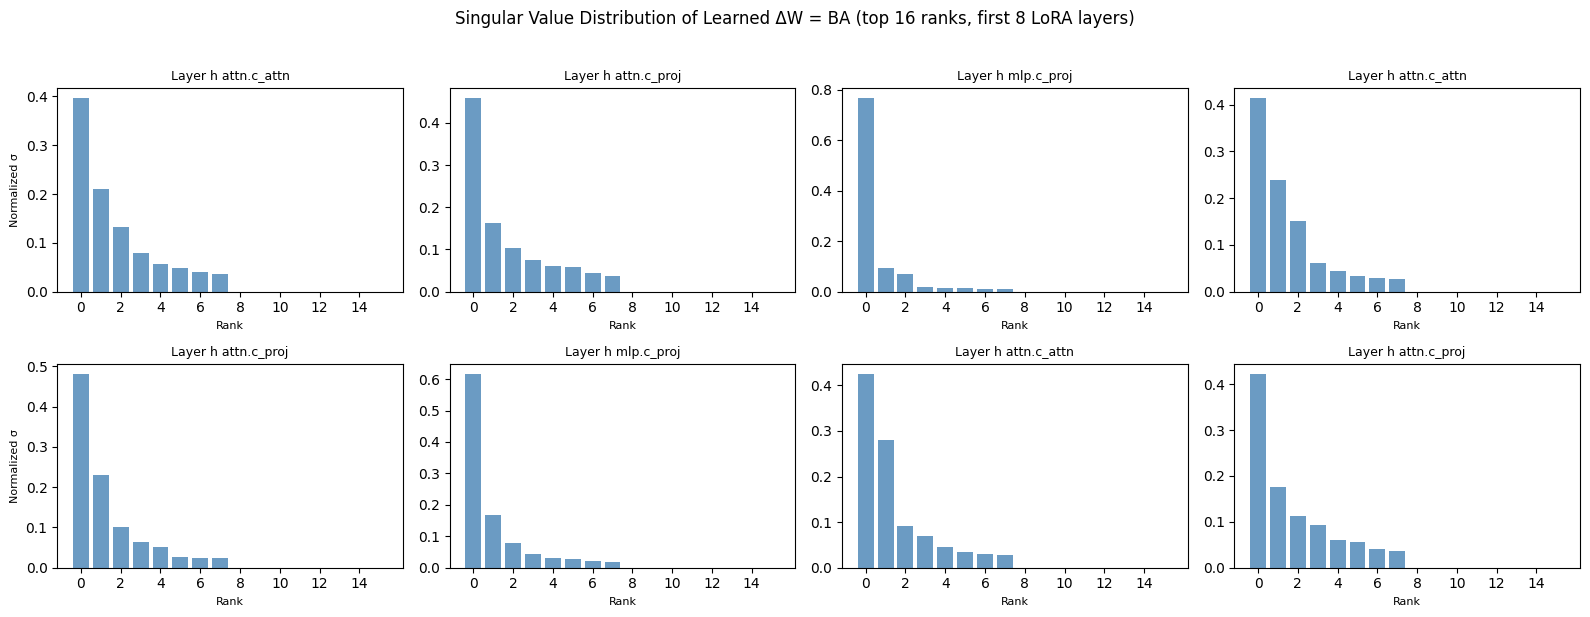

In [71]:
# We need a fresh LoRA model for analysis (since we merged the previous one)
# Let's train a quick one and analyze it

model_analysis = GPT2ForClassification(num_labels=2)
model_analysis = inject_lora(model_analysis, target_modules=['c_attn', 'c_proj'], r=8, alpha=16)
for param in model_analysis.classifier.parameters():
  param.requires_grad = True

# Quick train
print("Training for analysis...")
_ = train_model(model_analysis, train_loader, val_loader, epochs=3, lr=3e-4, device=device)

# Analyze the singular values of BA for each LoRA layer
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

idx = 0
for name, module in model_analysis.named_modules():
  if isinstance(module, LoRALinear) and idx < 8:
    with torch.no_grad():
        BA = (module.lora_B @ module.lora_A).cpu()
        _, S, _ = torch.linalg.svd(BA)

    S_norm = S / S.sum()
    short_name = name.split('.')[-2] + '.' + name.split('.')[-1]
    layer_num = name.split('.')[1] if 'h.' in name else '?'

    top_k = 16
    axes[idx].bar(range(top_k), S_norm[:top_k].numpy(), color='steelblue', alpha=0.8)
    axes[idx].set_title(f'Layer {layer_num} {short_name}', fontsize=9)
    axes[idx].set_xlabel('Rank', fontsize=8)
    axes[idx].set_xticks(range(0, top_k, 2))
    if idx % 4 == 0:
        axes[idx].set_ylabel('Normalized σ', fontsize=8)
    idx += 1

plt.suptitle('Singular Value Distribution of Learned ΔW = BA (top 16 ranks, first 8 LoRA layers)', y=1.02)
plt.tight_layout()
plt.show()

Notice how the singular values are concentrated. Even within the rank-8 adapter, most of the adaptation energy is focused in just a few directions. This further validates the low-rank hypothesis: the model doesn't even *use* all 8 dimensions equally. For sentiment classification, the adaptation is remarkably simple.

## 9. Comparison with HuggingFace PEFT

Our from-scratch implementation captures the essential idea, but production usage typically goes through HuggingFace's [PEFT library](https://github.com/huggingface/peft). Let's see how it compares. This is the "verify against established library" step.

In [72]:
!pip install peft -q


In [74]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import GPT2ForSequenceClassification

# Using HuggingFace's built-in classification model
hf_model = GPT2ForSequenceClassification.from_pretrained('gpt2', num_labels=2)
hf_model.config.pad_token_id = tokenizer.pad_token_id

# Configure LoRA with PEFT
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.0,
    target_modules=['c_attn', 'c_proj'],  # Same targets as our implementation
)

hf_model_peft = get_peft_model(hf_model, peft_config)

print("HuggingFace PEFT LoRA:")
hf_model_peft.print_trainable_parameters()

print("\nOur implementation:")
print_trainable_params(model_analysis)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


HuggingFace PEFT LoRA:
trainable params: 812,544 || all params: 125,253,888 || trainable%: 0.6487

Our implementation:
Trainable:    812,546 (0.65%)
Frozen:    124,439,808 (99.35%)
Total:     125,252,354


(812546, 125252354)

## 10. Beyond LoRA: The Landscape

LoRA opened the floodgates for parameter-efficient fine-tuning research. Here's a brief map of where the field has gone since:

**QLoRA** ([Dettmers et al., 2023](https://arxiv.org/abs/2305.14314)): Combines LoRA with 4-bit quantization of the base model. The frozen weights $W_0$ are stored in 4-bit NormalFloat format, cutting memory by another ~4×. This made fine-tuning LLaMA-65B possible on a single 48GB GPU. The key insight: quantization errors in the frozen weights are compensated for by the LoRA adapters during training.

**DoRA** ([Liu et al., 2024](https://arxiv.org/abs/2402.09353)): Decomposes the weight update into *magnitude* and *direction* components. The intuition is that full fine-tuning changes both the scale and direction of weight vectors, but LoRA's low-rank constraint makes it hard to independently control both. DoRA fixes this by separately learning a magnitude vector and applying LoRA only to the direction, consistently outperforming LoRA across tasks.

**Rank-Adaptive Methods** (AdaLoRA, DyLoRA): Instead of fixing the rank $r$ across all layers, these methods dynamically allocate rank based on layer importance. Some layers need more adaptation capacity than others, so why waste parameters on layers that barely change?

Each of these builds directly on the LoRA foundation we've implemented here.

## Key Takeaways

1. **LoRA works because of intrinsic dimensionality**: Fine-tuning weight updates live in a low-rank subspace. We don't need to update all $d \times k$ parameters. A rank-$r$ factorization $\Delta W = BA$ is sufficient.

2. **The parameter savings are dramatic and real**: For GPT-2, LoRA with $r=8$ reduces trainable parameters by ~48× per targeted layer while matching full fine-tuning accuracy.

3. **Zero additional inference latency**: After training, merge $W' = W_0 + \frac{\alpha}{r}BA$ and serve with the original architecture. No adapters, no routing, no extra computation.

4. **The initialization matters**: $B = 0$ ensures $\Delta W = 0$ at the start, so training begins exactly at the pre-trained checkpoint. The $\alpha/r$ scaling decouples rank choice from learning rate.

5. **Practical defaults**: Start with $r = 8$, $\alpha = 16$, targeting attention projections. Adjust rank up for complex tasks, down for simpler ones. Monitor the singular values of your trained adapters. If they're concentrated in the first few components, you can probably reduce rank.

## References

- [Hu et al. (2021) - LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- [Aghajanyan et al. (2020) - Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning](https://arxiv.org/abs/2012.13255)
- [Dettmers et al. (2023) - QLoRA: Efficient Finetuning of Quantized Language Models](https://arxiv.org/abs/2305.14314)
- [Liu et al. (2024) - DoRA: Weight-Decomposed Low-Rank Adaptation](https://arxiv.org/abs/2402.09353)
- [HuggingFace PEFT Library](https://github.com/huggingface/peft)